# Mandatory Assignment 1: Training and Evaluating Baseline Models
#### Group: Prakmas

In [187]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import weighted, average
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

## Description of the dataset
The dataset that the task is based on is the "Student Performance Factors".
"The dataset provides a comprehensive overview of various factors affecting student performance in exams.
It includes information on study habits, attendance, parental involvement, and other aspects influencing academic success." - https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

The target value is the exam score. To create a classification problem out of the dataset, this value will be encoded into categorical data.

The dataset does not have a real source. It instead claims to be created for simulating realistic scenarios for analyzing student performance factors. As such, the group has designed a fictional scenario to base this task on. The scenario is described in the next paragraph. To make the dataset more balanced, and since the data is generated rather than real, some adjustments has been made to the grade scale. The grades are created in a non-linear way from the exam score to create a more realistic grade distribution.

### Scenario
Exams done in the first half of the year can end up having a short time between grades being finalized and admission to schools and universities. To combat this problem the Norwegian school system has developed a prediction model for how well a student will do based on a set of data about the student. The grade given by the model is then used by the government when assigning students to different schools.

For this scenario it is considered more important for the model to get a higher grade correct than giving a higher grade than the real value. This will keep more opportunities available to students before the real grades are finalized. There is then more closure after the final grades are released, and more ambiguity when just the predicted grades available. This may differ depending on how this system is used. If it is used in a way that when too many students are predicted to get the same grade, the course will be temporarily be overfilled until the final grades are available, then it would work like intended. This is the basis for how the models are evaluated.

In [108]:
# Read the dataset
student_dataset = pd.read_csv('Dataset/StudentPerformanceFactors.csv')
# Uses existing column names baked into csv file.

# Show the first 5 rows to validate that the data import has been successful
student_dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [109]:
# Look at the implementation details, data types and missing data
student_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

## Data Processing

### Missing Values


In [110]:
# Count the number of missing values in the dataset
student_dataset.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [111]:
# Check how many rows include at least one missing value.
student_dataset.isna().any(axis=1).sum()

np.int64(229)

In [112]:
# Remove rows with missing values from the student performance dataset.
student_dataset = student_dataset.dropna()

# Check to see if there still are features with missing values.
student_dataset.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

### Separating the dataset into features and targets

In [113]:
features = student_dataset.drop('Exam_Score', axis=1)
targets = student_dataset['Exam_Score']
targets = targets.to_frame()
print(targets)

      Exam_Score
0             67
1             61
2             74
3             71
4             70
...          ...
6602          68
6603          69
6604          68
6605          68
6606          64

[6378 rows x 1 columns]


### Encoding the target value
Encoding Exam_Score and making it into a new column named Grades. The original Exam_Score column is left completely unchanged.

In [114]:
def gradesetter(points):
    if points < 60:
        return 'Fail'
    elif 60 <= points < 65:
        return 'D'
    elif 65 <= points < 69:
        return 'C'
    elif 69 <= points < 74:
        return 'B'
    else:
        return 'A'

targets['Grades'] = targets['Exam_Score'].map(gradesetter)

In [115]:
# Ordinal Encoding of the targets
encoder = OrdinalEncoder(categories=[['Fail', 'D', 'C', 'B', 'A']])
targets['Grades']= (encoder.fit_transform(targets[['Grades']]).astype(int))

### Splitting the dataset
Using the train_test_split() function from sklearn twice to first split the data into train/test sets.
Then it is further split a second time into train/test/validation sets by sending in the train set.
The target set splits are also stratified on the Grades category so that each set (train, test, validation) has equal amounts of each grade. This is done so that there exists not one set that has a disproportionate amount of a single grade.


In [116]:
features_train, features_test, targets_train, targets_test = train_test_split(
    features, targets,
    train_size=0.8, # Splitting 80% of the dataset into training. 0.8 * 1.0 = 0.8
    test_size=0.2, # Splitting 20% of the dataset into testing. 0.2 * 1.0 = 0.2
    random_state=21,
    stratify=targets['Grades'] # Stratified on Grades category
)

In [117]:
features_train, features_validation, targets_train, targets_validation = train_test_split(
    features_train, targets_train,
    train_size=0.75, # Splitting the 80% training set to only 60%. 0.75 * 0.80 = 0.60. One ends up with 60% training data.
    test_size=0.25, # Splitting the 80% training set to 20% validation data. 0.25 * 0.80 = 0.20. One ends up with 20% validation data.
    random_state=21,
    stratify=targets_train['Grades'] # Stratified on Grades category on the targets_train set (80% of the original set)
)

To summarize, The results from splitting the data are as following:
- 60% training
- 20% test data
- 20% validation data

In [118]:
print(features_train.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


### Encoding
The data is encoded in two main ways. The first one is using an ordinal encoder. This is used for the data that a order which should be retained for the ML-model to take into account. These values are specified in the "categories" parameter of the method. This specification allows the data to be contextually encoded so that the higher values is greater than the lower values. The other way of encoding which is used is a form of binary encoding. This is used for the data that only has two options, such as 'yes' or 'no' and 'female' or 'male'. These features uses a more direct approach of encoding, using pandas' replace function on the datasets.

The encoding is done on split datasets. The encoding will be done in the same way on all three datasets, but doing it after minimizes the risk of data leakage. Additionally, the original dataframe is kept intact, leaving only data in the split dataframes replaced. Originally the encoded data was added to a seperate column to retain the categorical data. Since the categorical data is retained in the original dataframe, it was deemed to be too much work for little gain to add an extra column. The encoded values will now simply replace the old value in the same column.

In [119]:
# - - - Ordinal data - - -
# - - Parental Involvement - -
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
features_train['Parental_Involvement']= encoder.fit_transform(features_train[['Parental_Involvement']])
features_validation['Parental_Involvement']= encoder.fit_transform(features_validation[['Parental_Involvement']])
features_test['Parental_Involvement']= encoder.fit_transform(features_test[['Parental_Involvement']])


# Previous way of encoding (straight into the unsplit dataframe)
#encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
#student_dataset['Parental_Involvement_Encoded'] = encoder.fit_transform(student_dataset[['Parental_Involvement']])
#print(student_dataset[['Parental_Involvement','Parental_Involvement_Encoded']])

In [120]:
# - - Access to Resources - -
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
features_train['Access_to_Resources']= encoder.fit_transform(features_train[['Access_to_Resources']])
features_validation['Access_to_Resources']= encoder.fit_transform(features_validation[['Access_to_Resources']])
features_test['Access_to_Resources']= encoder.fit_transform(features_test[['Access_to_Resources']])

In [121]:
# - - Motivation_Level - -
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
features_train['Motivation_Level']= encoder.fit_transform(features_train[['Motivation_Level']])
features_validation['Motivation_Level']= encoder.fit_transform(features_validation[['Motivation_Level']])
features_test['Motivation_Level']= encoder.fit_transform(features_test[['Motivation_Level']])

In [122]:
# - - Family_Income - -
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
features_train['Family_Income']= encoder.fit_transform(features_train[['Family_Income']])
features_validation['Family_Income']= encoder.fit_transform(features_validation[['Family_Income']])
features_test['Family_Income']= encoder.fit_transform(features_test[['Family_Income']])

In [123]:
# - - Teacher_Quality - -
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
features_train['Teacher_Quality']= encoder.fit_transform(features_train[['Teacher_Quality']])
features_validation['Teacher_Quality']= encoder.fit_transform(features_validation[['Teacher_Quality']])
features_test['Teacher_Quality']= encoder.fit_transform(features_test[['Teacher_Quality']])
# Since we removed the missing values beforehand, the encoding goes smoothly without interruptions

In [124]:
# - - Peer_Influence - -  
encoder = OrdinalEncoder(categories=[['Negative', 'Neutral', 'Positive']])
features_train['Peer_Influence']= encoder.fit_transform(features_train[['Peer_Influence']])
features_validation['Peer_Influence']= encoder.fit_transform(features_validation[['Peer_Influence']])
features_test['Peer_Influence']= encoder.fit_transform(features_test[['Peer_Influence']])

In [125]:
# - - Parental_Education_Level - -
encoder = OrdinalEncoder(categories=[['High School', 'College', 'Postgraduate']])
features_train['Parental_Education_Level']= encoder.fit_transform(features_train[['Parental_Education_Level']])
features_validation['Parental_Education_Level']= encoder.fit_transform(features_validation[['Parental_Education_Level']])
features_test['Parental_Education_Level']= encoder.fit_transform(features_test[['Parental_Education_Level']])

In [126]:
# - - Distance_from_Home - -
encoder = OrdinalEncoder(categories=[['Near', 'Moderate', 'Far']])
features_train['Distance_from_Home']= encoder.fit_transform(features_train[['Distance_from_Home']])
features_validation['Distance_from_Home']= encoder.fit_transform(features_validation[['Distance_from_Home']])
features_test['Distance_from_Home']= encoder.fit_transform(features_test[['Distance_from_Home']])

In [127]:
# - - - Binary data - - -
# - - Gender - -
print("A quick check to see if the encoding worked: ")
print("Original data:")
print(features_train.Gender.value_counts(), "\n")
features_train['Gender'] = features_train['Gender'].replace({'Female':0, 'Male':1})
print("Encoded data:")
print(features_train.Gender.value_counts())
features_validation['Gender']= features_validation['Gender'].replace({'Female':0, 'Male':1})
features_test['Gender']= features_test['Gender'].replace({'Female':0, 'Male':1})

A quick check to see if the encoding worked: 
Original data:
Gender
Male      2243
Female    1583
Name: count, dtype: int64 

Encoded data:
Gender
1    2243
0    1583
Name: count, dtype: int64


In [128]:
# - - Extra Curricular Activities - -

features_train['Extracurricular_Activities'] = features_train['Extracurricular_Activities'].replace({'No':0, 'Yes':1}).astype(int)
features_validation['Extracurricular_Activities'] = features_validation['Extracurricular_Activities'].replace({'No':0, 'Yes':1}).astype(int)
features_test['Extracurricular_Activities'] = features_test['Extracurricular_Activities'].replace({'No':0, 'Yes':1}).astype(int)


In [129]:
# - - Learning_Disabilites - -
features_train['Learning_Disabilities'] = features_train['Learning_Disabilities'].replace({'No':0, 'Yes':1}).astype(int)
features_validation['Learning_Disabilities'] = features_validation['Learning_Disabilities'].replace({'No':0, 'Yes':1}).astype(int)
features_test['Learning_Disabilities'] = features_test['Learning_Disabilities'].replace({'No':0, 'Yes':1}).astype(int)


In [130]:
# - - School_Type - -
features_train['School_Type'] = features_train['School_Type'].replace({'Public':0, 'Private':1}).astype(int)
features_validation['School_Type'] = features_validation['School_Type'].replace({'Public':0, 'Private':1}).astype(int)
features_test['School_Type'] = features_test['School_Type'].replace({'Public':0, 'Private':1}).astype(int)


In [131]:
# - - Internet_Access - -
features_train['Internet_Access'] = features_train['Internet_Access'].replace({'No':0, 'Yes':1}).astype(int)
features_validation['Internet_Access'] = features_validation['Internet_Access'].replace({'No':0, 'Yes':1}).astype(int)
features_test['Internet_Access'] = features_test['Internet_Access'].replace({'No':0, 'Yes':1}).astype(int)


## Analysis


### Univariate Analysis

In [132]:
# Creating an encoded dataset to use for analysis, ignores index to avoid duplicate indices
analysis_dataset = pd.concat([features_train, features_validation, features_test], ignore_index=True)

print(analysis_dataset['Internet_Access'])

0       1
1       1
2       1
3       1
4       0
       ..
6373    0
6374    1
6375    1
6376    1
6377    1
Name: Internet_Access, Length: 6378, dtype: int64


C:\Users\47480\AppData\Local\Temp\ipykernel_34296\2493484405.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  analysis_dataset.hist(ax=ax)


array([[<Axes: title={'center': 'Hours_Studied'}>,
        <Axes: title={'center': 'Attendance'}>,
        <Axes: title={'center': 'Parental_Involvement'}>,
        <Axes: title={'center': 'Access_to_Resources'}>],
       [<Axes: title={'center': 'Extracurricular_Activities'}>,
        <Axes: title={'center': 'Sleep_Hours'}>,
        <Axes: title={'center': 'Previous_Scores'}>,
        <Axes: title={'center': 'Motivation_Level'}>],
       [<Axes: title={'center': 'Internet_Access'}>,
        <Axes: title={'center': 'Tutoring_Sessions'}>,
        <Axes: title={'center': 'Family_Income'}>,
        <Axes: title={'center': 'Teacher_Quality'}>],
       [<Axes: title={'center': 'School_Type'}>,
        <Axes: title={'center': 'Peer_Influence'}>,
        <Axes: title={'center': 'Physical_Activity'}>,
        <Axes: title={'center': 'Learning_Disabilities'}>],
       [<Axes: title={'center': 'Parental_Education_Level'}>,
        <Axes: title={'center': 'Distance_from_Home'}>, <Axes: >,
       

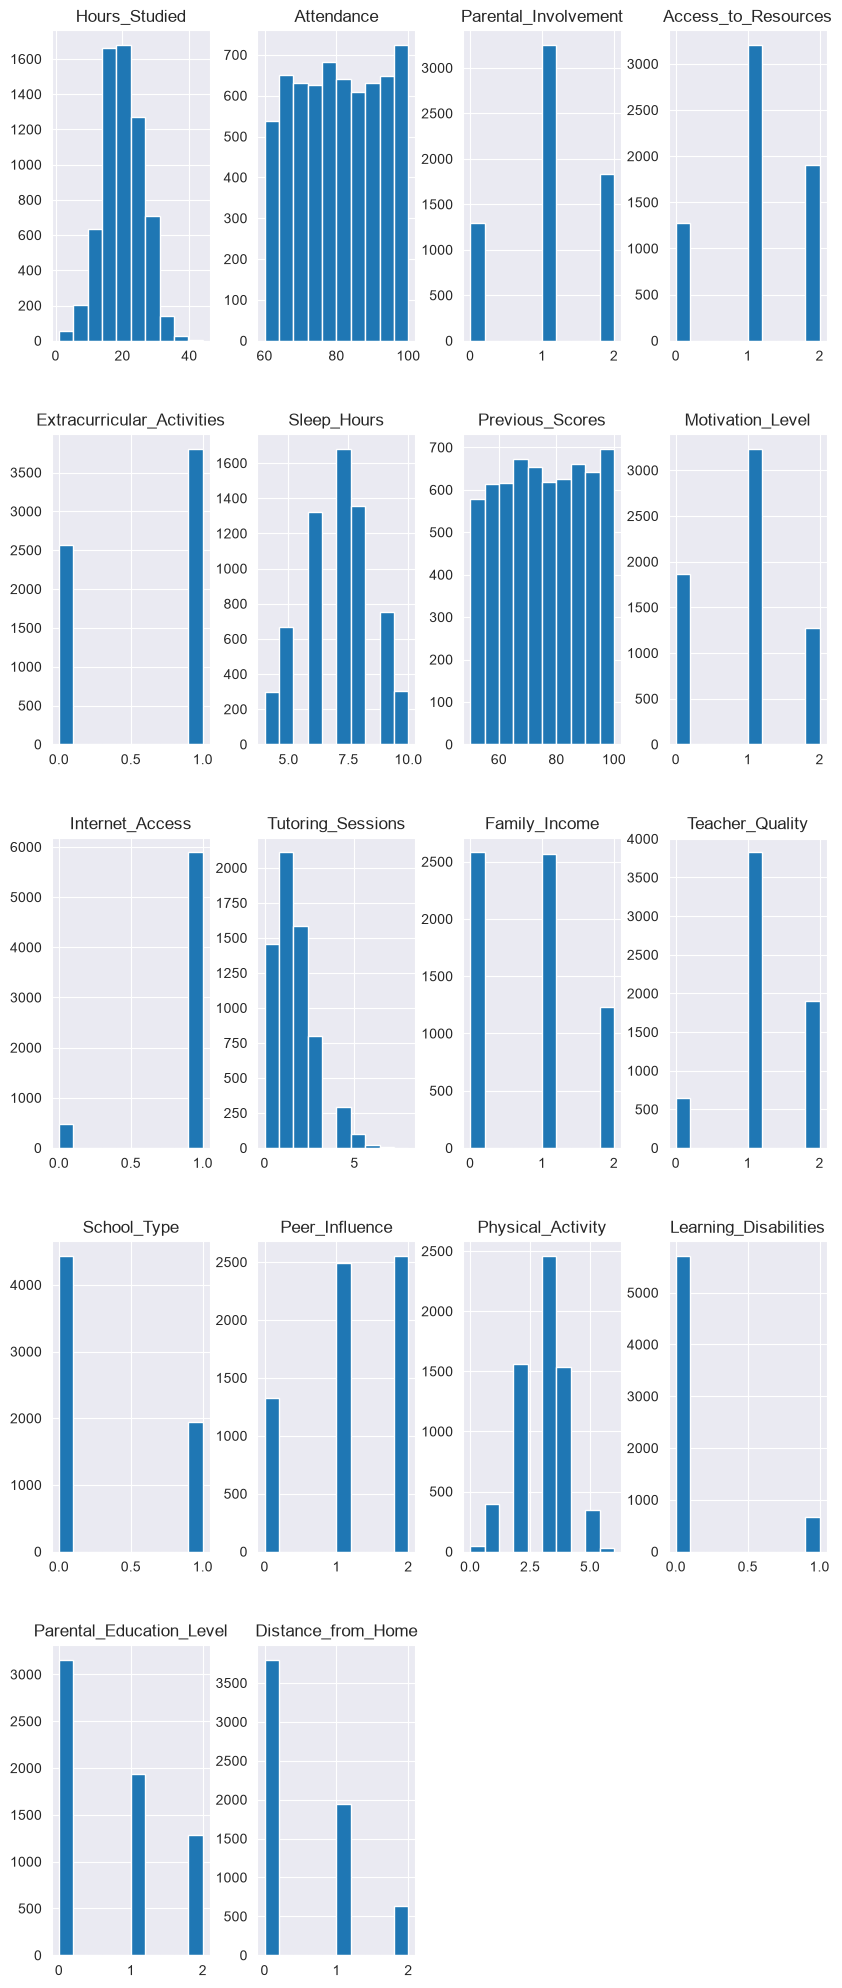

In [133]:
#Plotting the columns with numeric values into histograms
fig, ax = plt.subplots(1,1, figsize=(10,25))
analysis_dataset.hist(ax=ax)

We can clearly see that the previous exam scores were much more evenly spread, while the final exam scores were vastly in the range of 60-80 points. The exam scores seem to follow a normal distribution, while the previous scores are more of a uniform distribution. 

<Axes: ylabel='Density'>

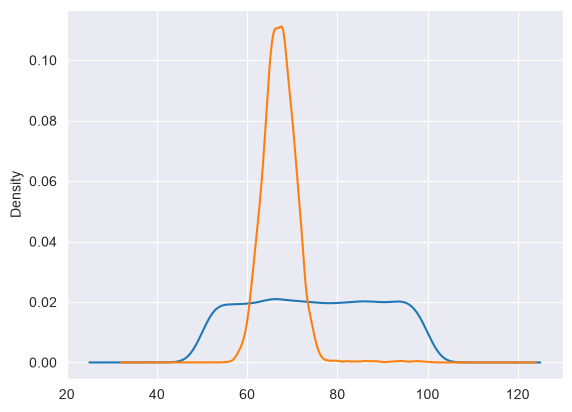

In [134]:
#Plotting a KDE of Previous Scores and Final Score to get a closer look at the distribution
analysis_dataset['Previous_Scores'].plot.kde()
student_dataset['Exam_Score'].plot.kde()

It's clear that the exam scores were much more concentrated around 60-80 points than the previous scores. As of now it seems like the exam was much more difficult than previous tests. We originally thought the exam might be curved, but that doesn't make much sense because these are the actual scores, not the grades. 

<Axes: >

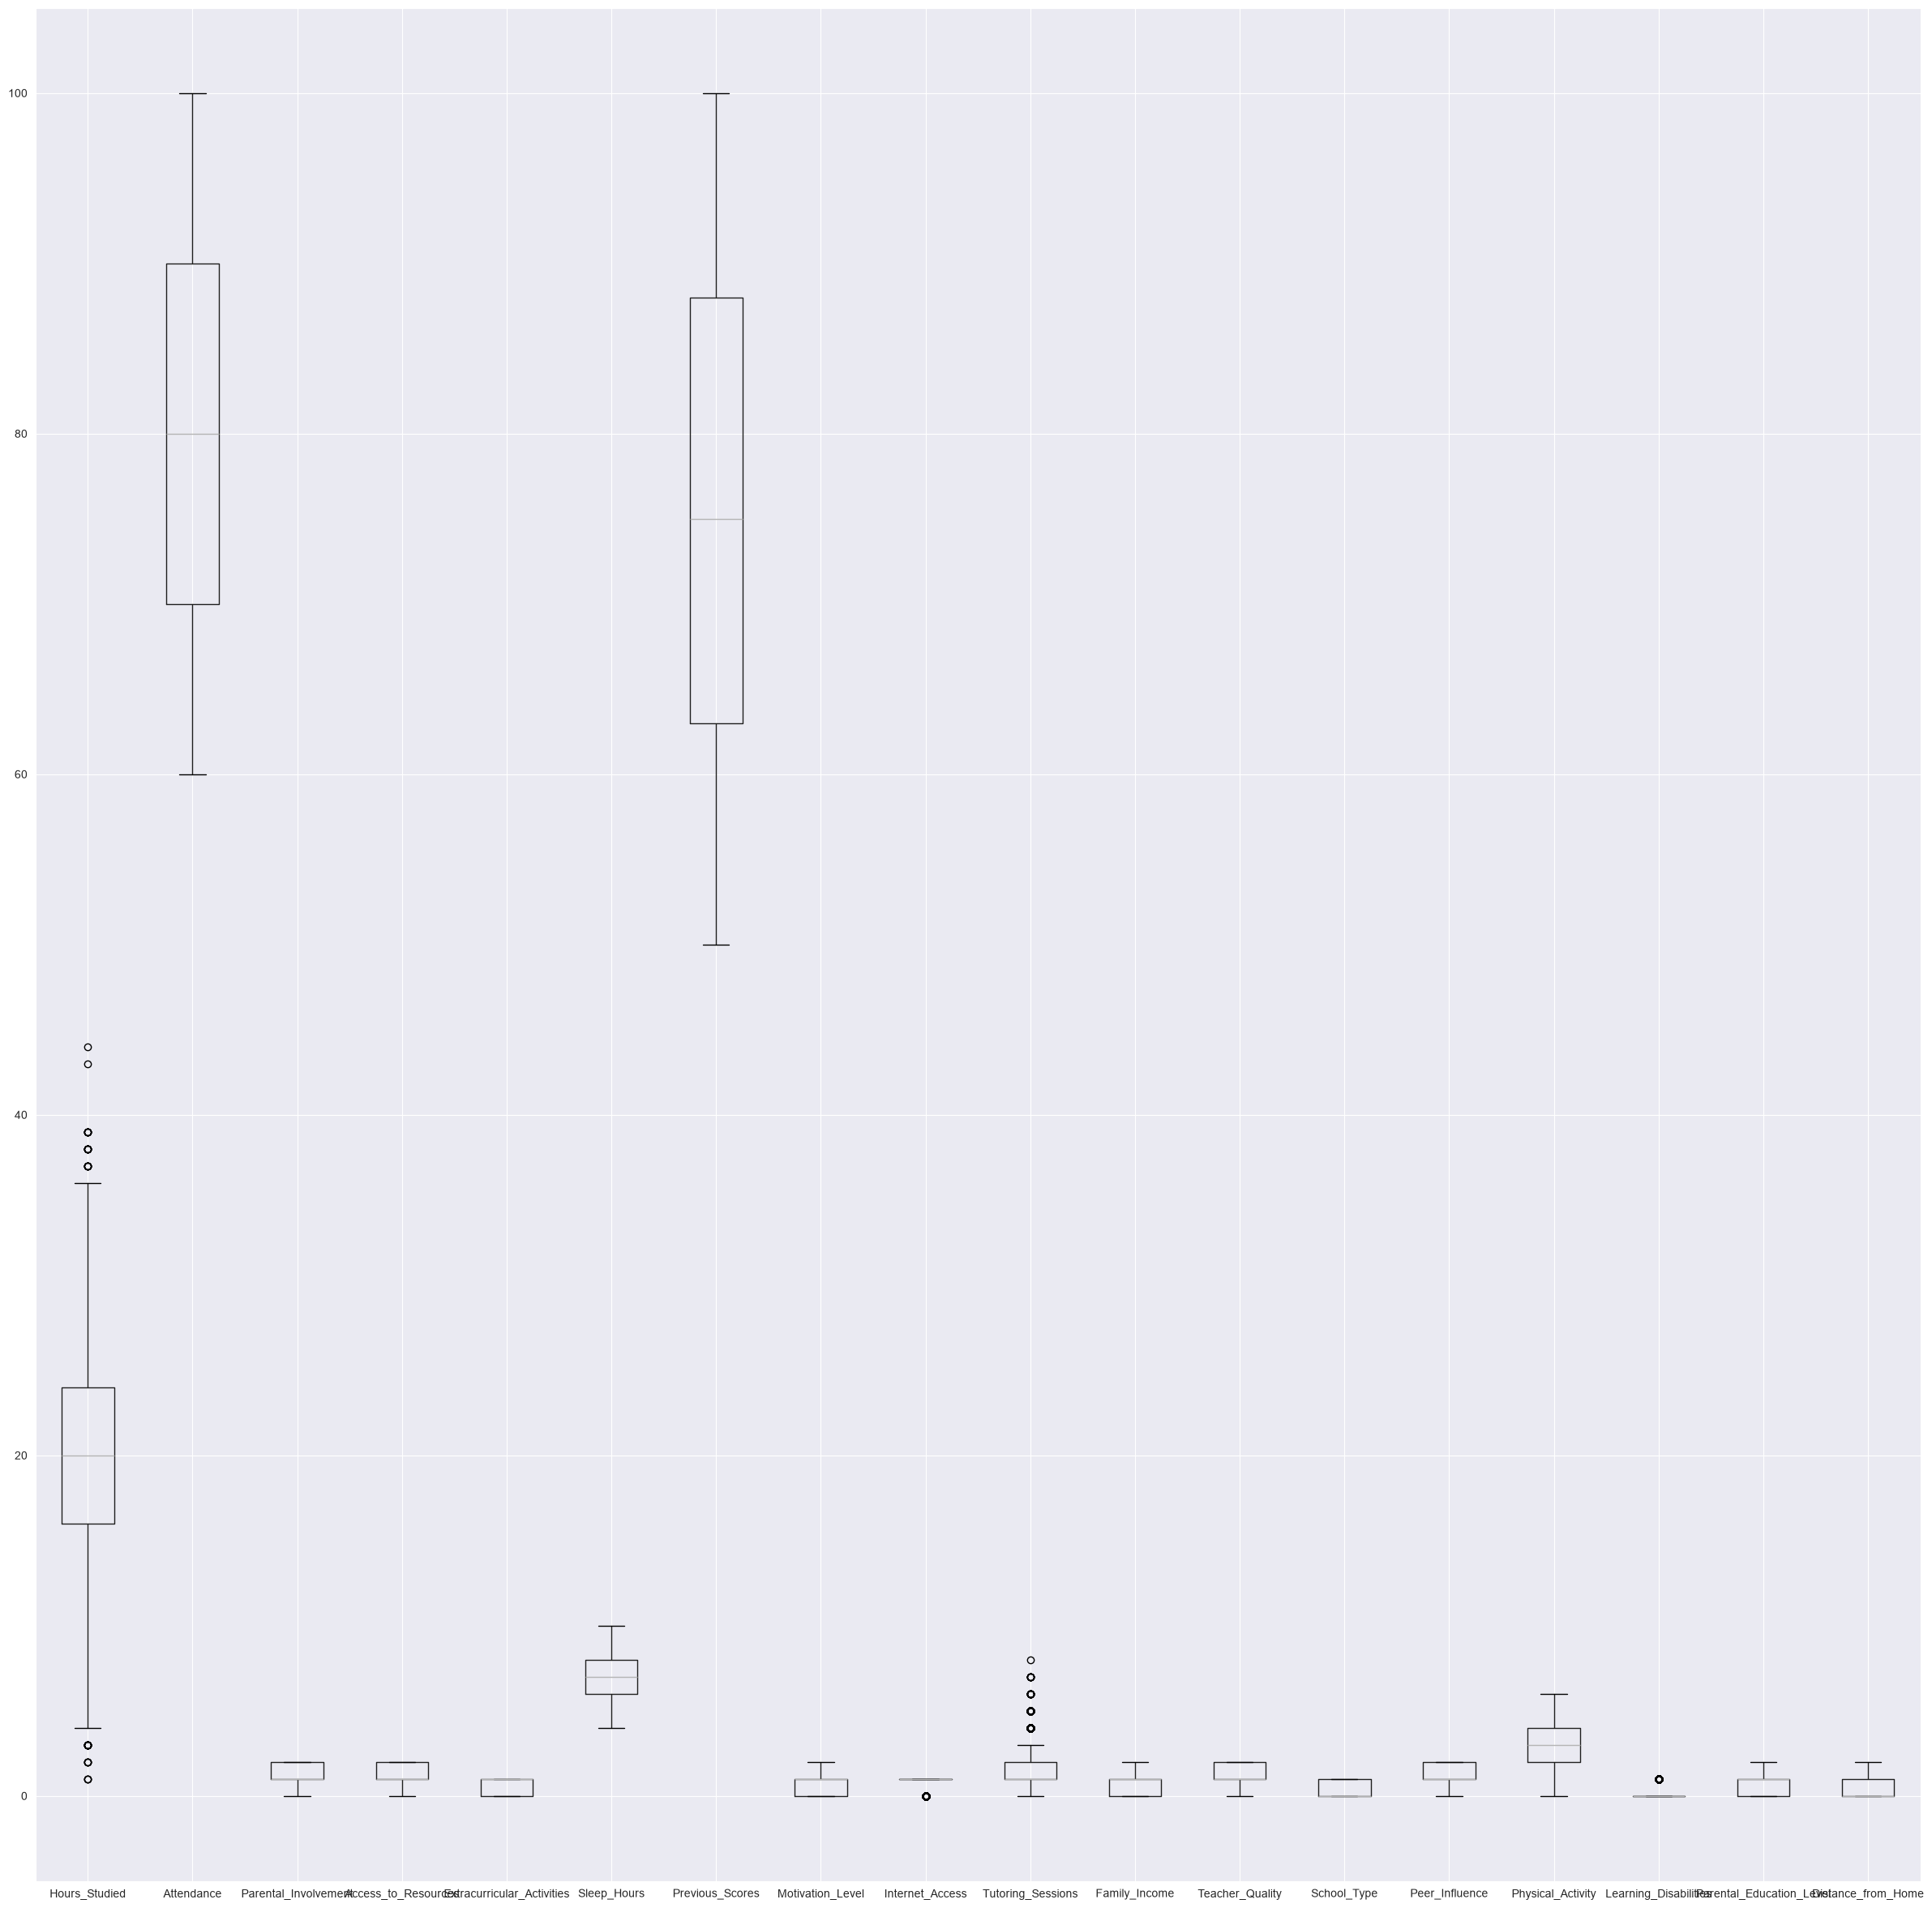

In [135]:
#Plotting the boxplots for the dataset to see which ones are close in the distribution, then separating them into plots with fewer boxplots. We see that Attendance, Previous_Scores and Exam_Scores seem close, and Hours_Studied matches well with Sleep_Hours.
fig, ax = plt.subplots(1,1,figsize=(30, 30))
analysis_dataset.boxplot()

<Axes: >

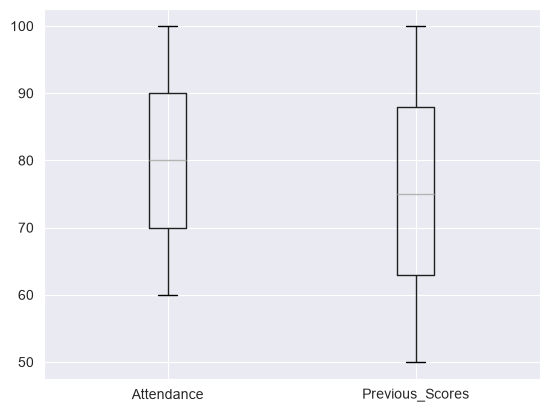

In [136]:
Score_features = ["Attendance","Previous_Scores"]
analysis_dataset[Score_features].boxplot()

The Exam_Score box plot is much more narrow than the other two, and it's the only one with any outliers. There are people that have scored 75+ on the exam, but there are not that many of them. As there are no exam scores below around 54, it seems like the test might have had some easy questions that most students were able to answer, and some very hard questions that pushed a few students into the outliers. As for the attendance, it seems like there was a minimum of 60% mandatory attendance needed to take the exam. 

<Axes: >

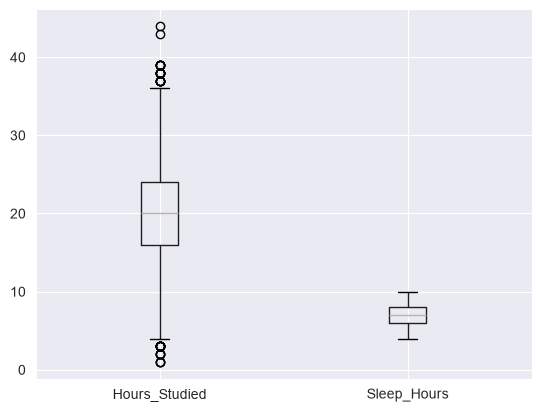

In [137]:
Score_features = ["Hours_Studied","Sleep_Hours"]
analysis_dataset[Score_features].boxplot()

Most students study about 15-25 hours each week, and sleep around 7-8 hours each day. There are some outliers who studied above 37 hours each week and below 4 hours each week. 

<Axes: >

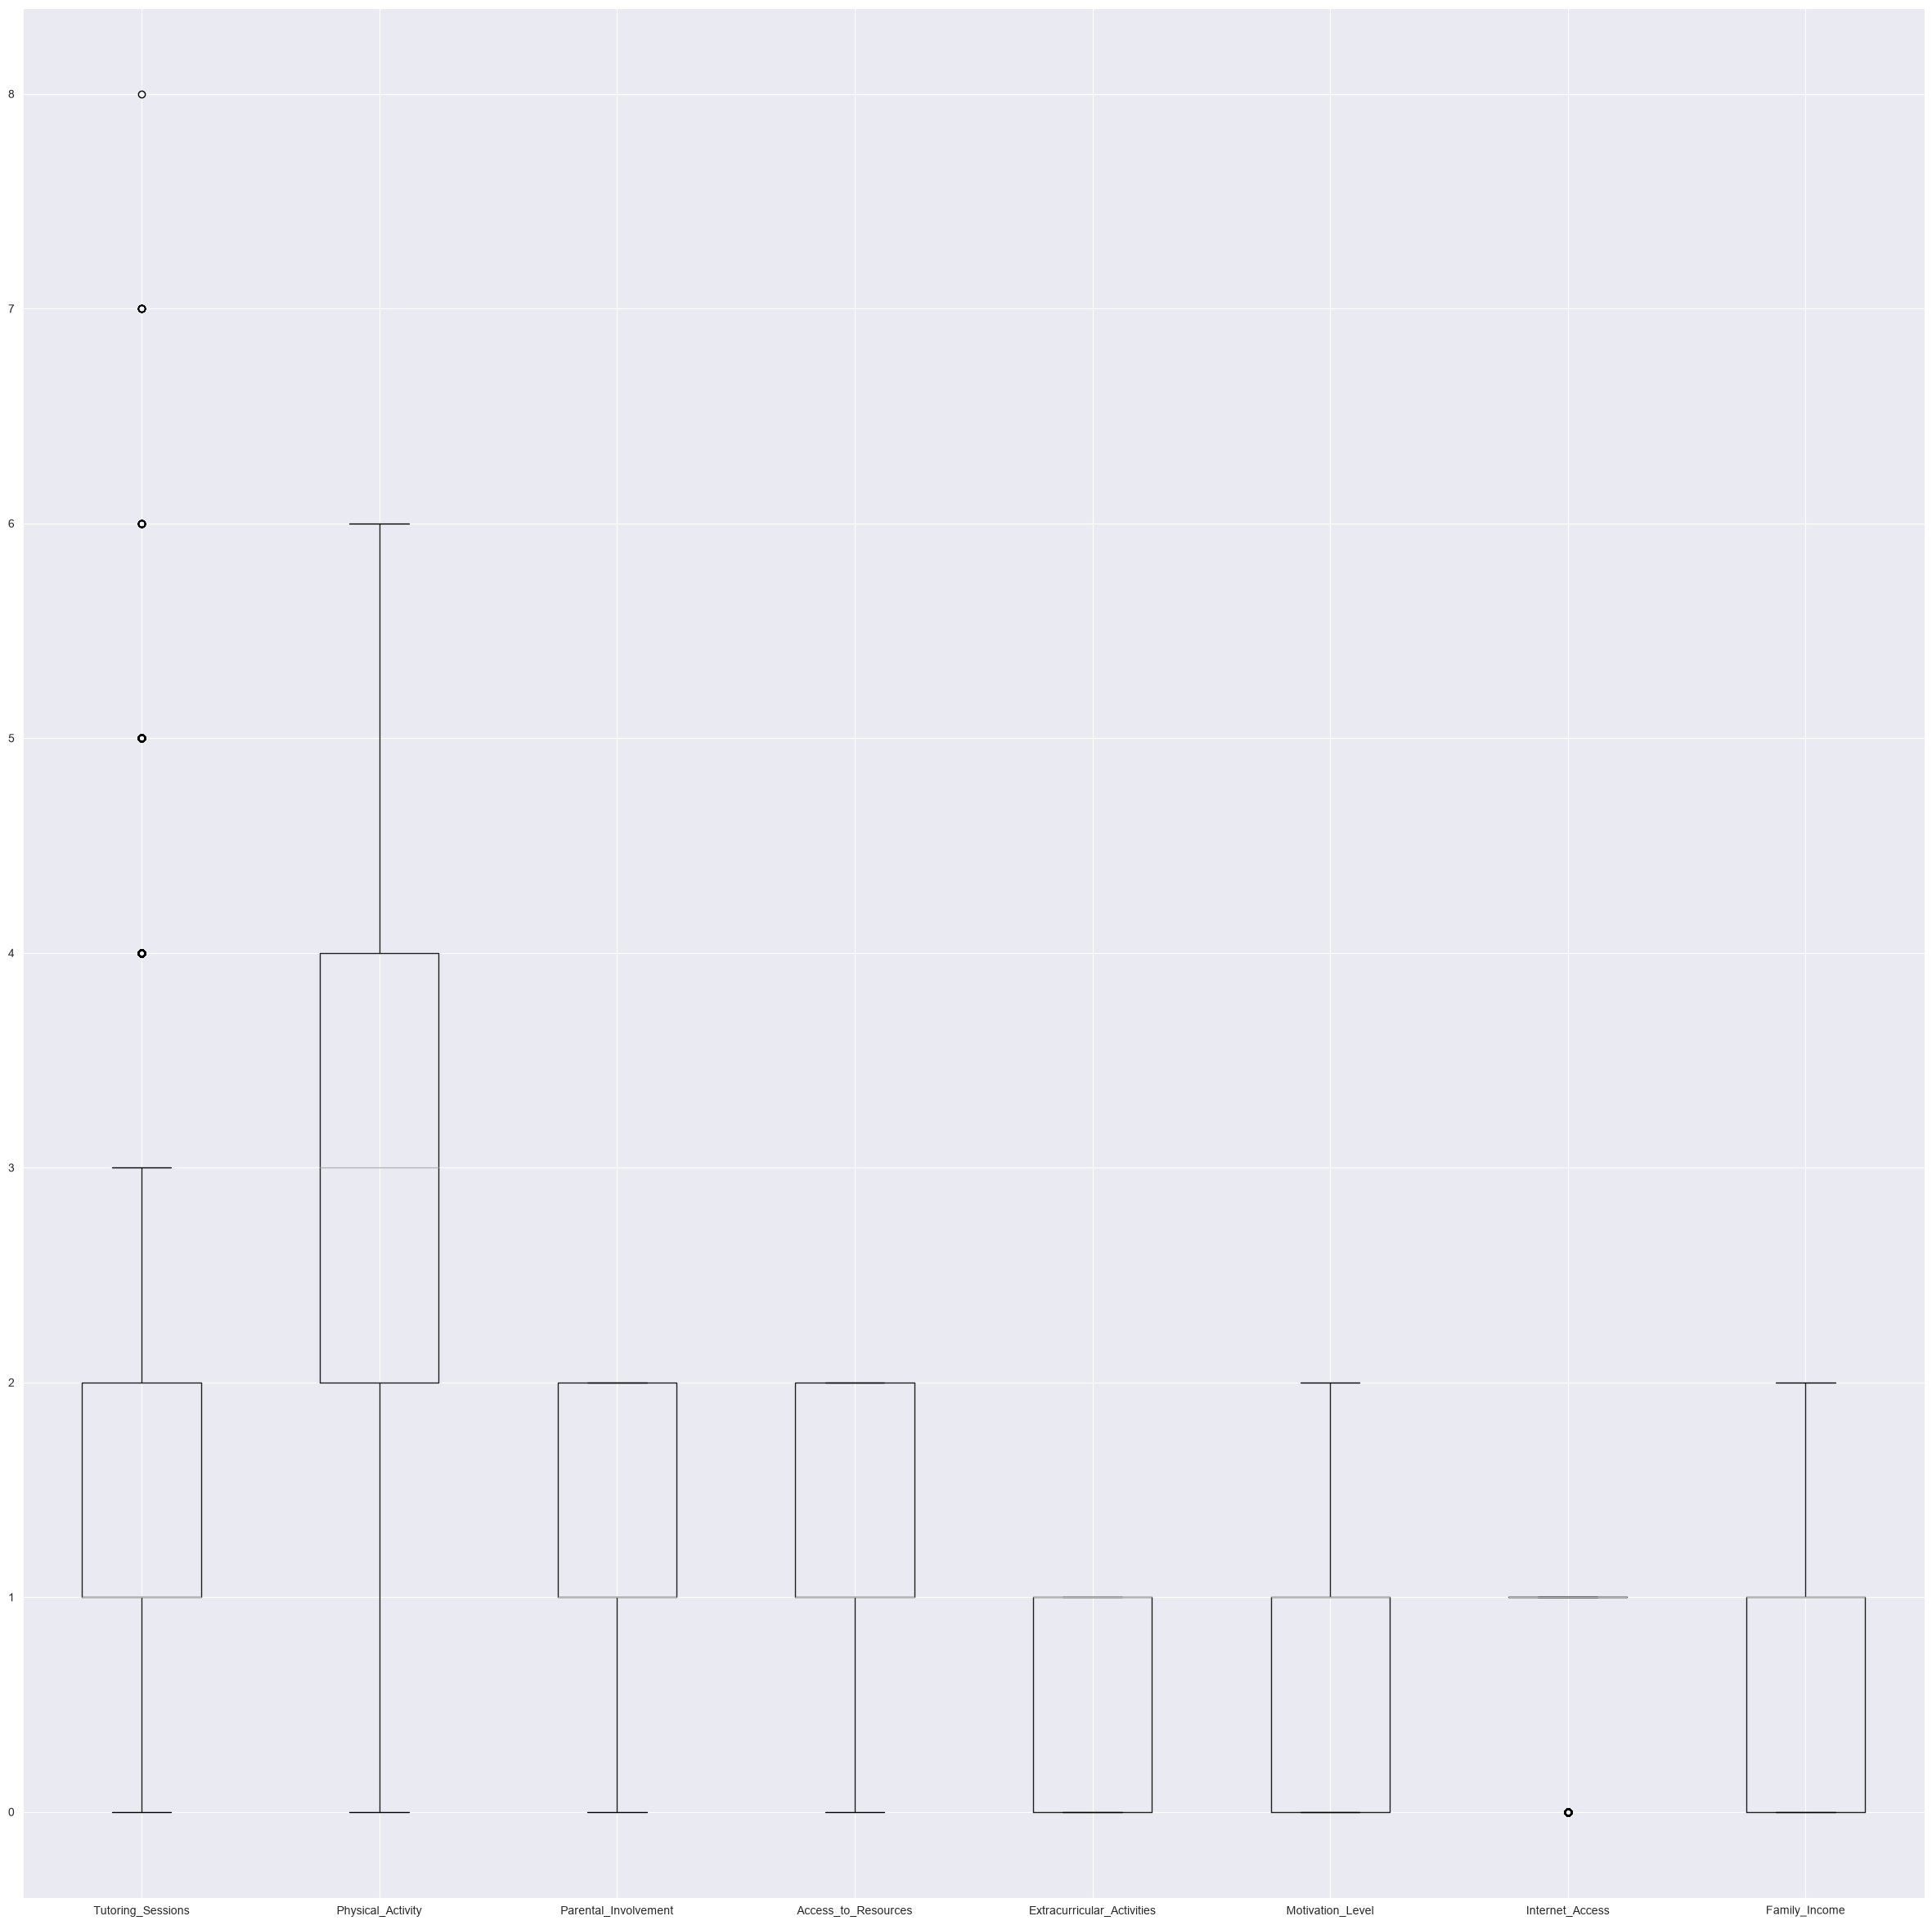

In [138]:

#Plotting the rest of the features together as they seem similar in how they're distributed. 
Rest_features = [
    "Tutoring_Sessions",
    "Physical_Activity",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income"
]
fig, ax = plt.subplots(1,1,figsize=(30, 30))
analysis_dataset[Rest_features].boxplot()

When it comes to tutoring sessions, it seems like the majority of students had between 0-3 sessions, with outliers reaching all the way up to 8 tutoring sessions. As for Internet Access, there are very few students with no internet access. The Internet_Access_Encoded box is barely visible so let's put it by itself to see clearly what it says. 

<Axes: >

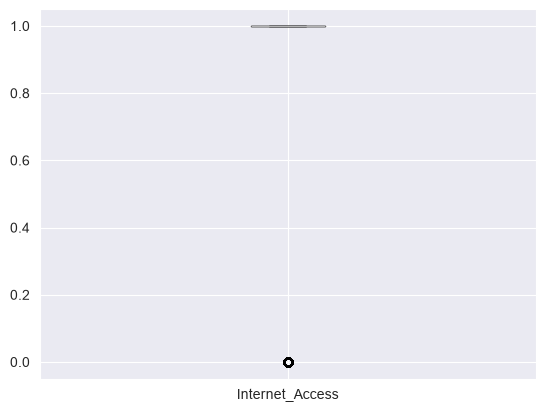

In [139]:
analysis_dataset[['Internet_Access']].boxplot()

### Multivariate Analysis
In this part of the analysis, the features will be analyzed in relation to each other.
#### Correlation



<Axes: >

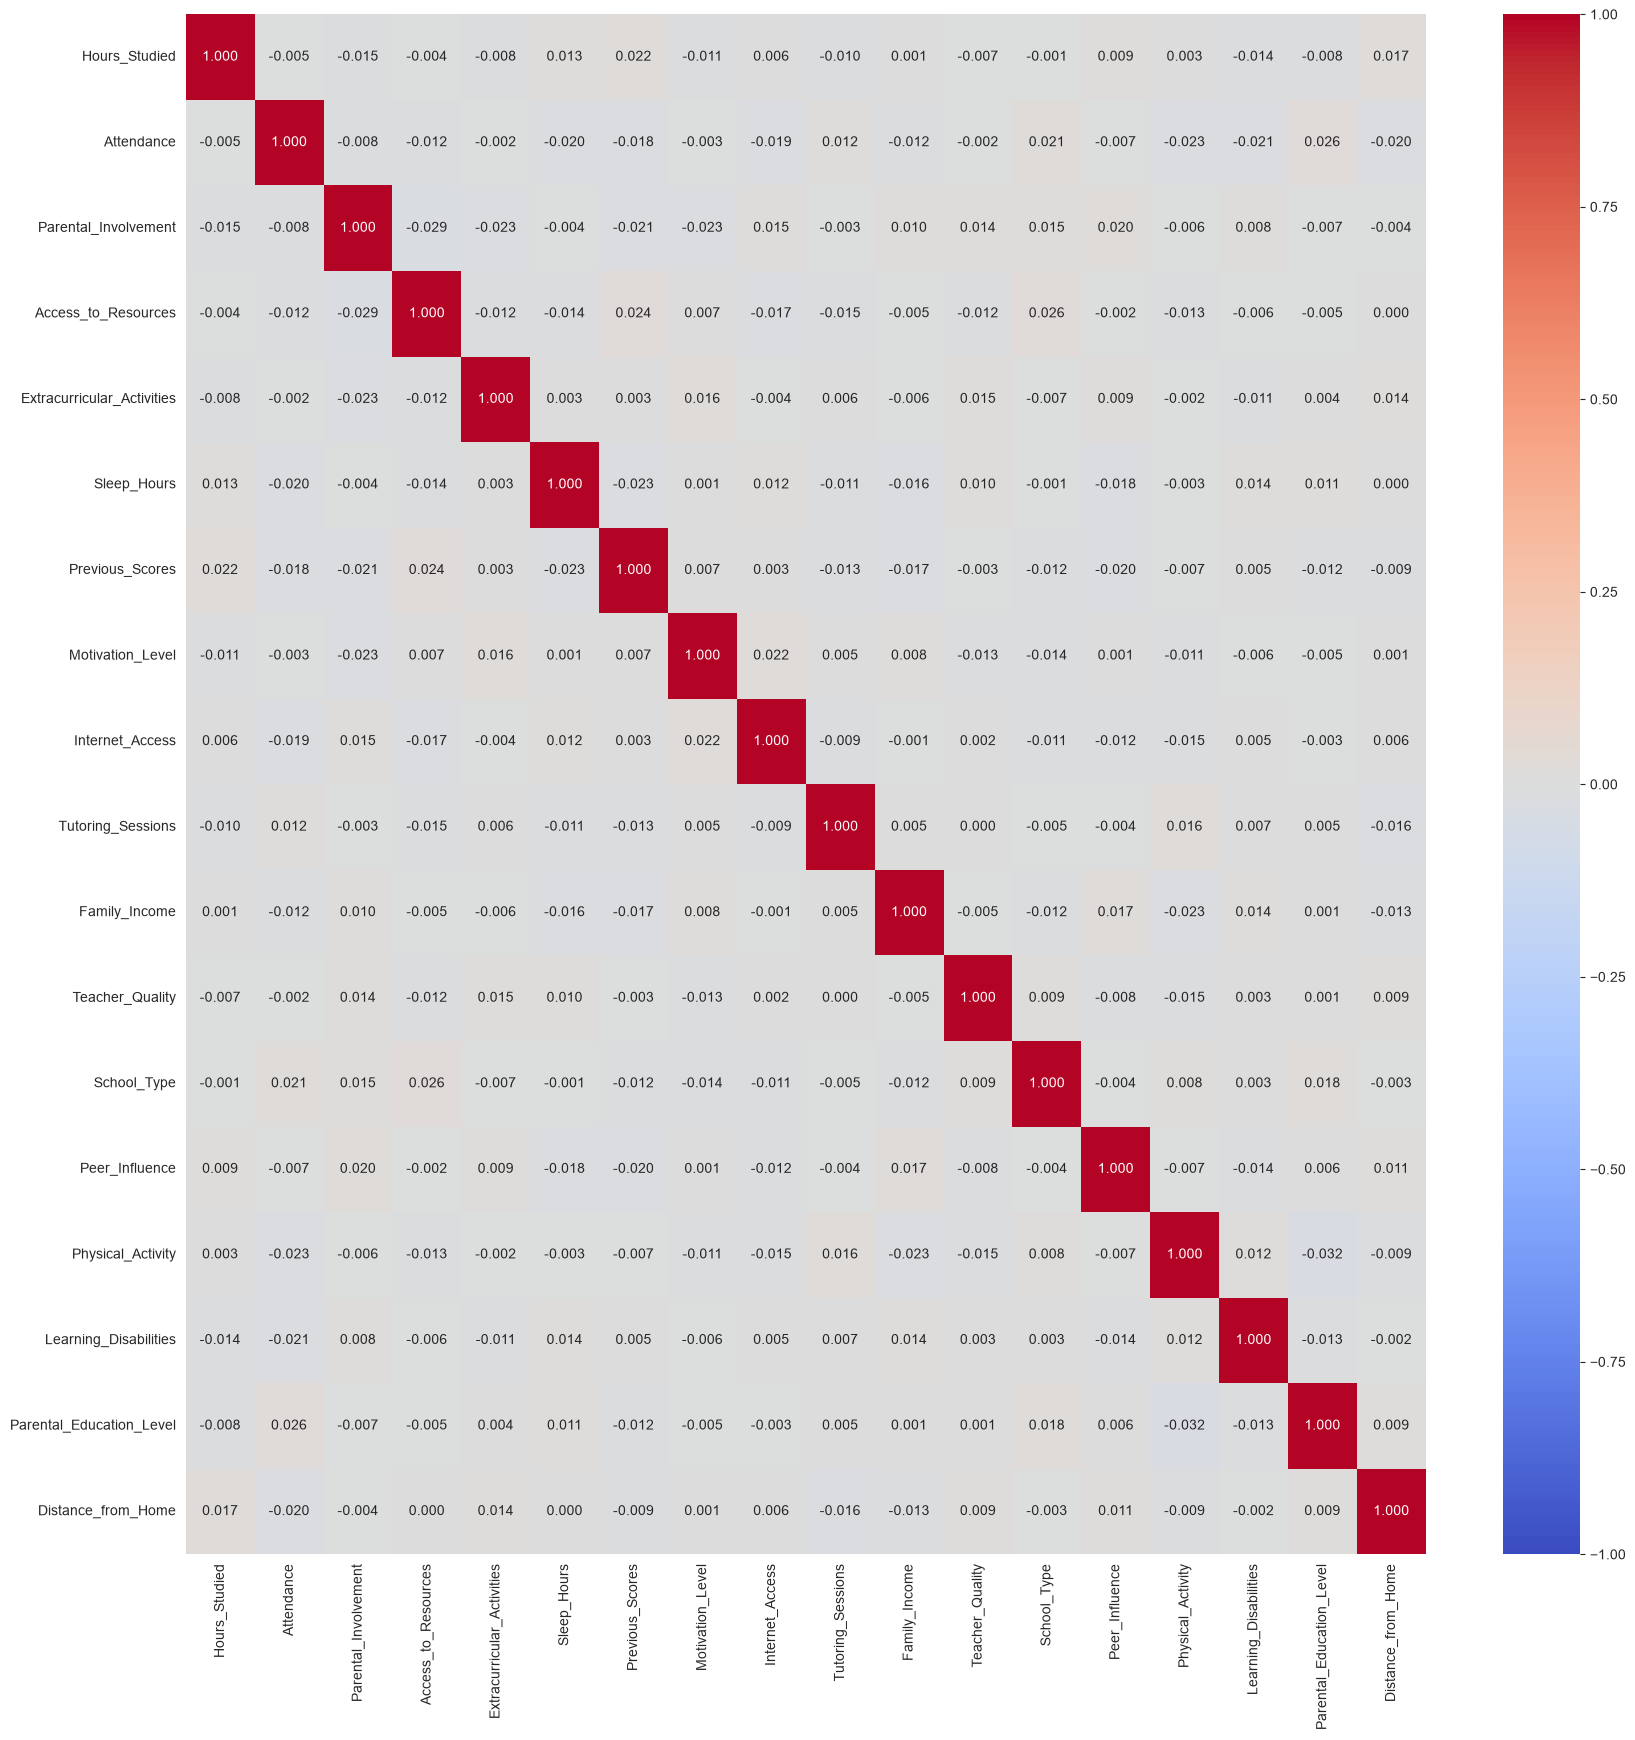

In [140]:
# Correlation gradient map.

# Computes the pairwise correlation between each feature.

# This method will only use numerical features.
# A lot has changed since this graph was introduced. I don't think it needs the parameter numeric_only=True anymore, but it is kept for future reference.
correlation = analysis_dataset.corr(numeric_only=True)
# Shows the correlation between the features in a heatmap.
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)


#### Results
The results of the correlation graph shows that none of the features are correlated in any notable degree. This means that all the individual features provides unique data to the model, rather than a two or more features giving the same information and making them redundant.

#### Scatterplot
To further investigate the correlation, scatterplots be used. These will show the correlation between two features. The more linear the scatterplot is, the more correlated the features are. Since there is virtually no correlation between the features of the dataset, the scatterplots that will be shown are have many scattered dots. This is an indication of low correlation between features.

To showcase some scatterplots, pairs of features that might be thought to have correlation, if taking the domain into account, is shown.


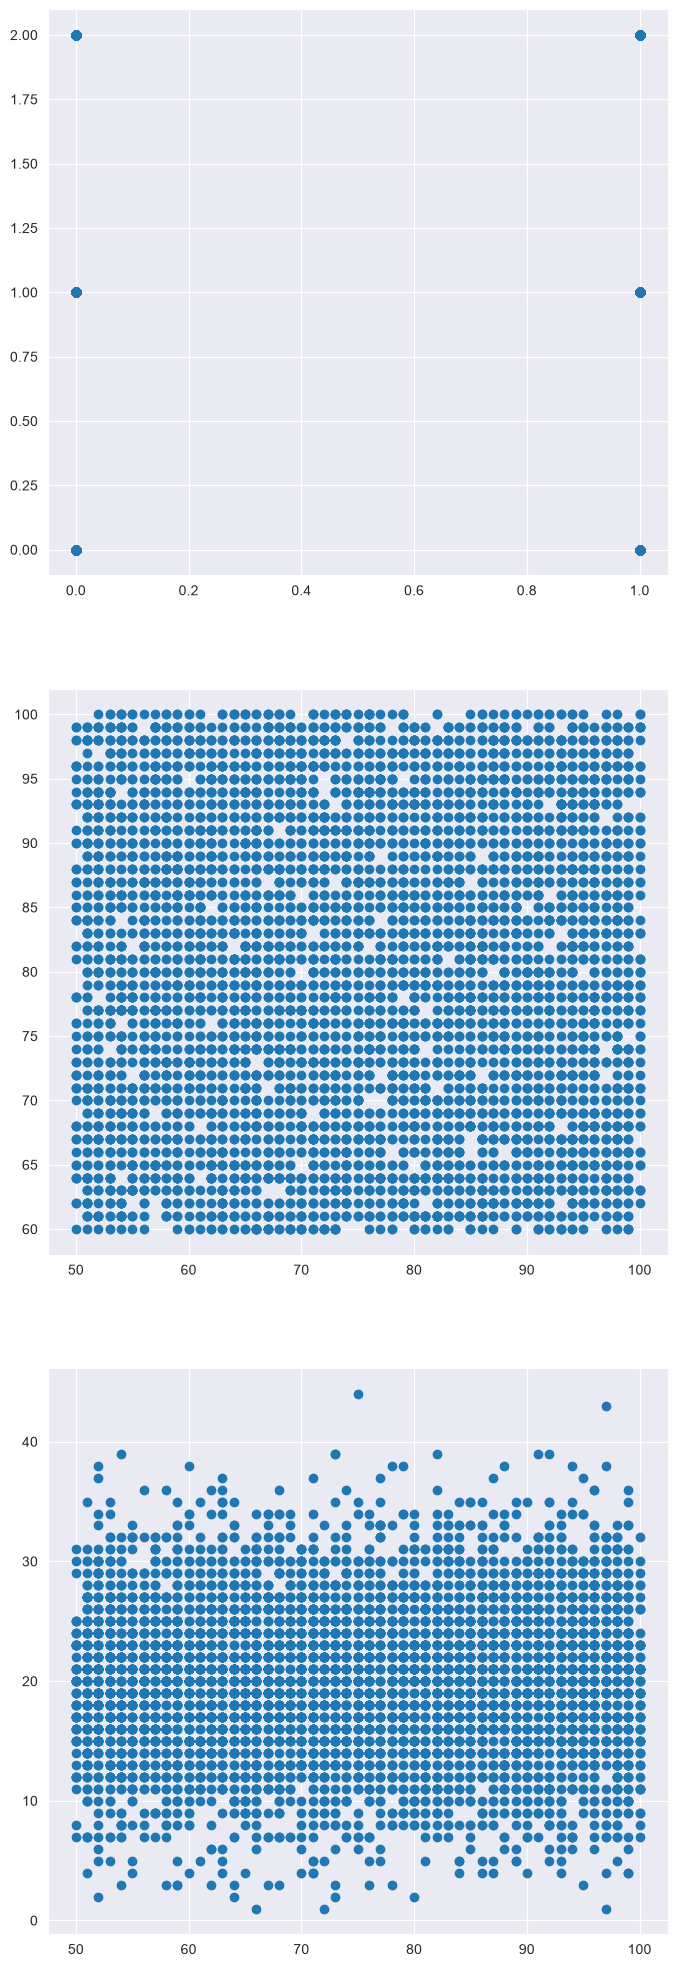

In [141]:
# Scatterplot.
fig, ax = plt.subplots(3, 1, figsize=(8,25))

ax[0].scatter(analysis_dataset['School_Type'], analysis_dataset['Family_Income'])
ax[1].scatter(analysis_dataset['Previous_Scores'], analysis_dataset['Attendance'])
ax[2].scatter(analysis_dataset['Previous_Scores'], analysis_dataset['Hours_Studied'])


As can be seen by the scatterplots, they are not very helpful as the data is either too discrete or is heavily scattered. The last two scatterplots is an example of very uncorrelated features.

To show more features, a pairplot can be used. This plot combines multivariate and univariate analysis by including each features' correlation to each other as well as its own distribution. The plot takes the shape of a matrix, where each cell represents a scatterplot or histogram of their correlation or distribution respectively. Discrete values does not look good in a scatterlpot. This is because of the excessive overplotting, derived by the number of instances massively outnumbering the amount of possible values for the relevant features. Therefore, these values are excluded and will be dealt with later. Naturally, categorical values are then also excluded.

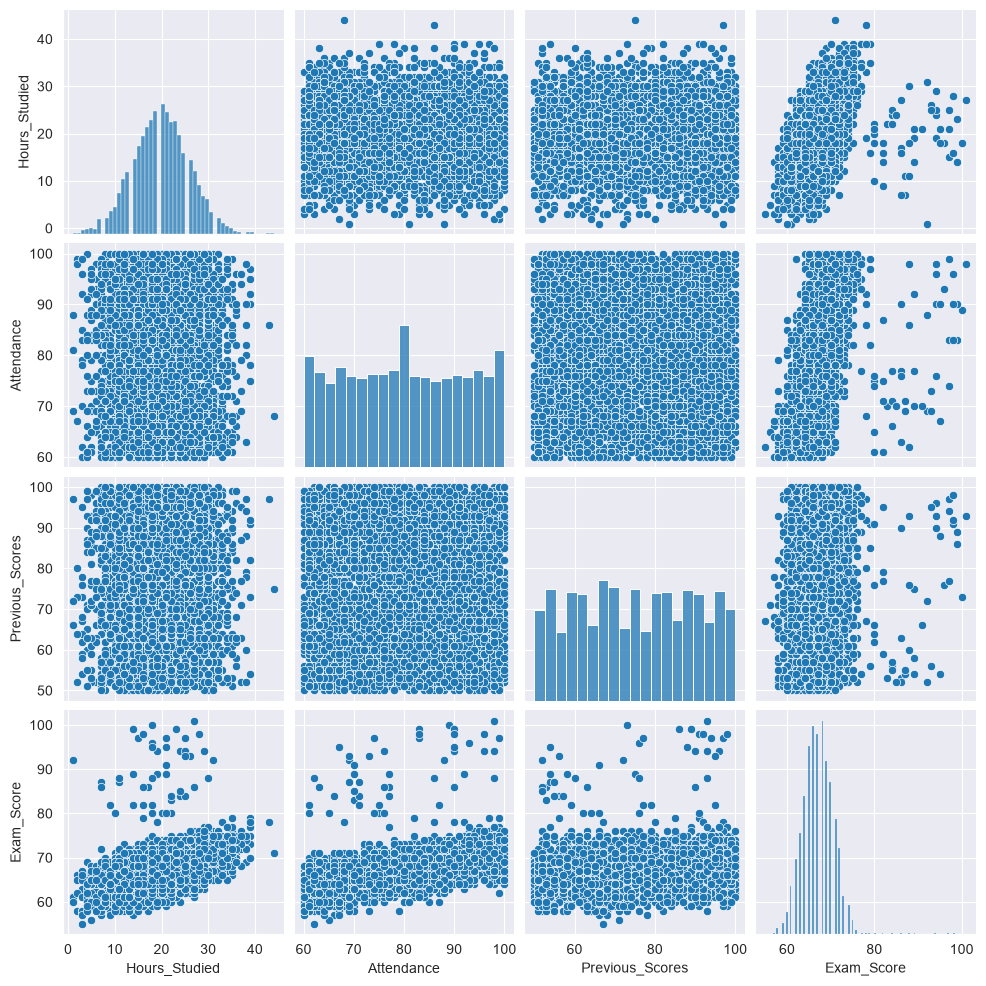

In [142]:
# Pair plot
# For the purpose of keeping this plot readable, by virtue of size and discrete values, categorial data is excluded from the plot. This is done with the vars parameter, which specifies which columns(of the dataset) should be included.
sns.pairplot(student_dataset, vars=["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score"])

#### Results
Here one can see that the features have no correlation, as previously shown. More interestingly, one can see that the features have correlation with the target value, Exam_Score. Bar some outliers, Hours_Studied and Attendance have dots that seemingly follows a regression line. Here the correlation seems positive. This means that the higher the hours studied and attendance are, the more likely it is that a student gets a better score on the test. This makes sense when taking the domain into consideration. Previous_Scores and Exam_Score also has dots following a line, but this one does not rise or fall in any considerable matter. This is an indication that there may not be a lot of correlation between the Previous_Scores and Exam_Score.

To further investigate this, a correlation matrix can be used. Other features are included in this investigation as well to get a more broad picture of how the target is correlated to the features. Due to the way the encoding has been done, this comes at a cost of number of instances. However, since stratified sampling has been used, the relation between the different target values should be similar across the split datasets. The training dataset will be used, since it has the most instances.



<Axes: >

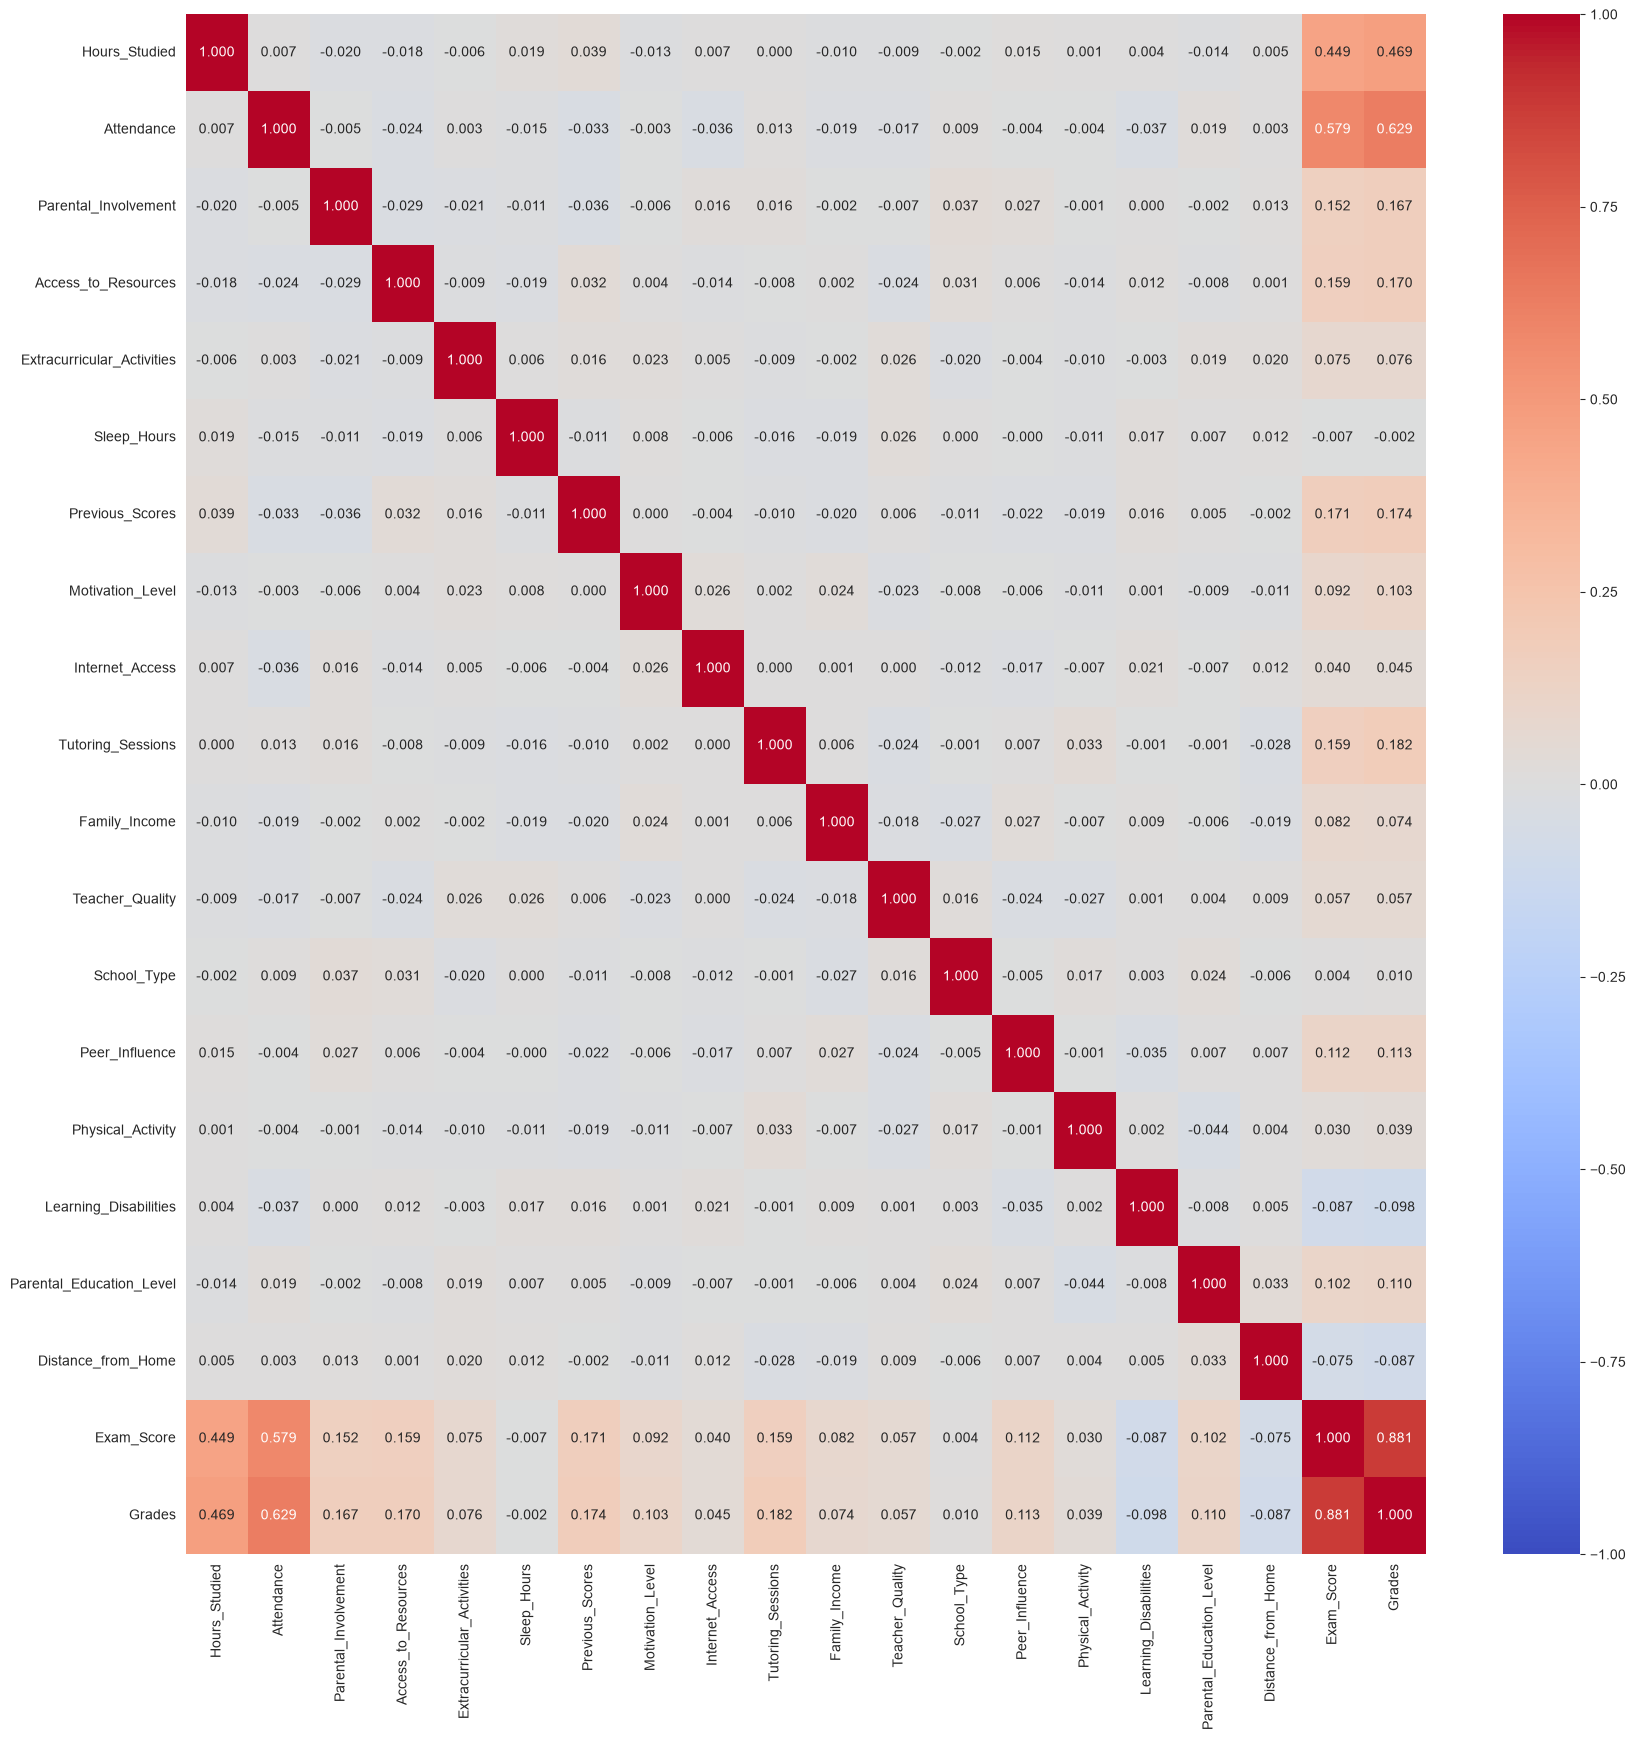

In [143]:
# Preliminary step:
# Create a temporary dataframe which combines encoded features and targets.
analysis_dataset_wtargets = pd.merge(features_train, targets_train, left_index=True, right_index=True)

# Correlation matrix which include exam score.
correlation = analysis_dataset_wtargets.corr(numeric_only=True)

# Shows the correlation with a heatmap.
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)

#### Results
The graph shows that multiple features has some correlation with the exam score. Distance from home and Learning disabilities have a slight negative correlation, while the rest has no or positive correlation. The features with the largest correlation to the exam score are the aforementioned Hours studied and Attendance. Attendance has the strongest correlation of all the features, but is not enough to be traditionally considered a strong correlation.

This dataset has some good properties when it comes to correlation. It is generally undesirable to have correlation between the features. This means that two or more features give the same information. They are therefore redundant. This redundancy increases the model complexity for no benefit, which can lead to overfitting and slower performance from a computational perspective. The model can also get worse performance from a quality perspective. This is through a problem called multicollinearity which makes it difficult for some models to differentiate between the correlated features' impact on the target value. This will again cause the model to be more sensitive to small changes in data. Multicollinearity is a problem which impacts certain models more than others. Of the three baseline models this assignment handles, linear regression is the model most impacted by multicollinearity.

While correlation between features is a bad thing, correlation between features and the target value is generally a good thing. This makes it easier for the model to predict the target value since the features give useful data about what the target might be. Circling back to the first statement of the previous paragraph. This dataset has practically no correlation between the features, and some correlation between some features and the target value. This makes the dataset reasonably good to work with.

#### Crosstables
To better showcase the relationship between discrete features, crosstables can be used. Each cell in the table corresponds to a percentage value of how many instances of the two feature belongs to a specific value of another feature. This doesn't directly illustrate correlation because the cells' percentage is weighted to the total amount cells rather than one axis. For example if the first the column is a binary option and the rows has three possible values, the distribution on the rows are affected by the distribution along the columns (See first crosstable). One can therefore not easily see the distribution along one axis. Four of the crosstables are therefore made to be normilized along one of the axis to more clearly illustrate the correlation between the features.

Since crosstables can be done on any combination of discrete features, the crosstables shown below are not exhaustive.

<Axes: xlabel='Motivation_Level', ylabel='Tutoring_Sessions'>

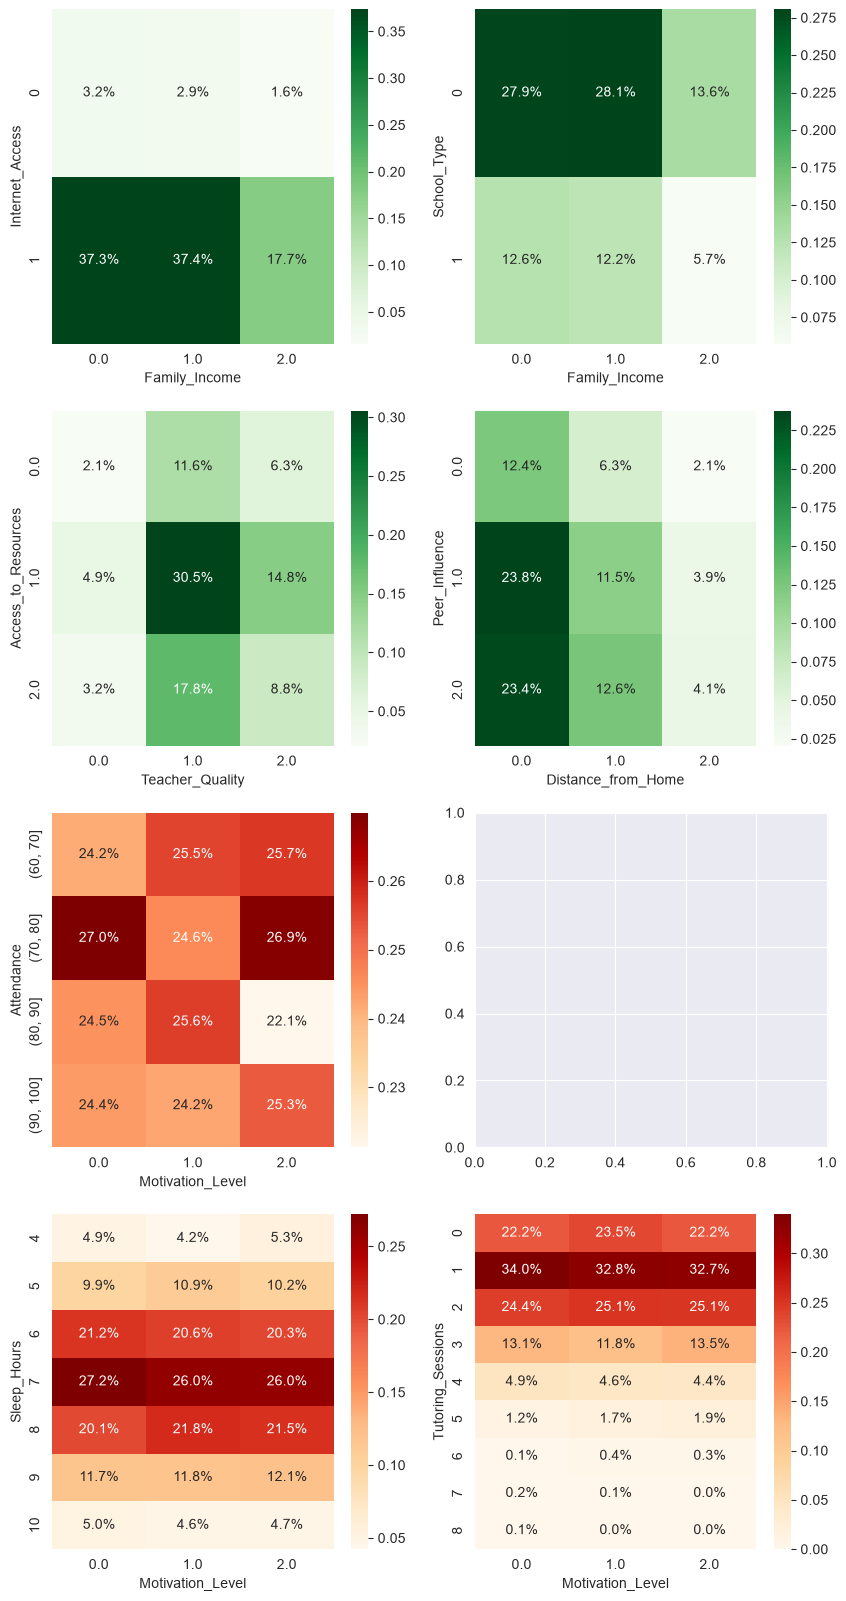

In [144]:
# Crosstables.
fig, ax = plt.subplots(4, 2, figsize=(10,20))

# Create the crosstable objects
xtable1 = pd.crosstab(analysis_dataset['Internet_Access'],
                      analysis_dataset['Family_Income'], normalize=True)
xtable2 = pd.crosstab(analysis_dataset['School_Type'],
                      analysis_dataset['Family_Income'], normalize=True)
xtable3 = pd.crosstab(analysis_dataset['Access_to_Resources'],
                      analysis_dataset['Teacher_Quality'], normalize=True)
xtable4 = pd.crosstab(analysis_dataset['Peer_Influence'],
                      analysis_dataset['Distance_from_Home'], normalize=True)


# Attendance has a lot of values, and need to be grouped into smaller bins for
# the table to be readable.
bins = [60, 70, 80, 90, 100]
attendance_grouped = pd.cut(analysis_dataset['Attendance'], bins)
xtable5 = pd.crosstab(attendance_grouped,
                      analysis_dataset['Motivation_Level'], normalize="columns")
# Use the same grouping for the dataset which include targets.
attendance_grouped_wtargets = pd.cut(analysis_dataset_wtargets['Attendance'], bins)
# xtable6 = pd.crosstab(analysis_dataset_wtargets['Motivation_Level'],
#                      analysis_dataset_wtargets['wait for exam grade'], normalize="columns")
xtable7 = pd.crosstab(analysis_dataset['Sleep_Hours'],
                      analysis_dataset['Motivation_Level'], normalize="columns")
xtable8 = pd.crosstab(analysis_dataset['Tutoring_Sessions'],
                      analysis_dataset['Motivation_Level'], normalize="columns")


# Show the crosstables as heatmaps.
sns.heatmap(xtable1, cmap='Greens', annot=True, fmt='.1%', ax=ax[0, 0])
sns.heatmap(xtable2, cmap='Greens', annot=True, fmt='.1%', ax=ax[0, 1])
sns.heatmap(xtable3, cmap='Greens', annot=True, fmt='.1%', ax=ax[1, 0])
sns.heatmap(xtable4, cmap='Greens', annot=True, fmt='.1%', ax=ax[1, 1])

sns.heatmap(xtable5, cmap='OrRd', annot=True, fmt='.1%', ax=ax[2, 0])
# sns.heatmap(xtable6, cmap='OrRd', annot=True, fmt='.1%', ax=ax[2, 1])
sns.heatmap(xtable7, cmap='OrRd', annot=True, fmt='.1%', ax=ax[3, 0])
sns.heatmap(xtable8, cmap='OrRd', annot=True, fmt='.1%', ax=ax[3, 1])

#### Results
From these tables one can closer analyze the lack of correlation. It is easier to see the correlation, or lack thereof, on the four last tables. The tables with motivation level shows that there are low cross-feature correlation. Either by having a uniform distribution of feature values across the motivation levels, or, as is the case with motivation level and attendance, the values are scattered with no clear pattern. For the exam score and attendance there is more of a pattern forming. One can see that for values of higher attendance, there are a higher percentage of instances with higher grades.

The first four tables show the context for both values. For example in the first table, there are a lot more people with internet access than not. It also shows that there are fewer people with high family income, than the other two categories. Since the percentages are similarly distributed along both axis, the graph shows that these features are not correlated. Closing in on this example, the value of high family income and internet access is the following fraction: 17.7/1.6 which roughly equates to 11. Doing the same calculation for the other two family income yields a relation of 11,7 and 12.9. This is a slight increase, which can indicate some minor correlation, but not a correlation of any significance.

## Data Processing part 2
### Normalization
The inputs are normalized using mean normalization. Inputs that are encoded as categories are not normalized. This is done after the analysis to retain the original values from the dataset in the analysis.


In [145]:
# Inputs that are to be normalized. These will be passed into the different features dataFrames.
inputs_to_normalize = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]

In [146]:
# Finding the mean, minimum, and maximum in the features_train dataset.
train_mean = features_train[inputs_to_normalize].mean()
train_min = features_train[inputs_to_normalize].min()
train_max = features_train[inputs_to_normalize].max()

In [147]:
# Mean normalization formula
def mean_normalization_func(data_frame: pd.DataFrame) -> pd.DataFrame:
    normalized_dataframe = (data_frame - train_mean) / (train_max - train_min)
    return normalized_dataframe


In [148]:
# Normalizing the features by using the function above.
features_train[inputs_to_normalize] = (mean_normalization_func(features_train[inputs_to_normalize]))

features_validation[inputs_to_normalize] = (mean_normalization_func(features_validation[inputs_to_normalize]))

features_test[inputs_to_normalize] = (mean_normalization_func(features_test[inputs_to_normalize]))

In [149]:
# Printing to check if normalization has been done correctly
print(features_train[inputs_to_normalize].describe())

       Hours_Studied    Attendance   Sleep_Hours  Previous_Scores  \
count   3.826000e+03  3.826000e+03  3.826000e+03     3.826000e+03   
mean   -4.016071e-17 -1.170000e-16 -3.505357e-17    -1.176964e-16   
std     1.583614e-01  2.906909e-01  2.423681e-01     2.901814e-01   
min    -4.980122e-01 -5.016924e-01 -5.077104e-01    -4.980763e-01   
25%    -1.032754e-01 -2.516924e-01 -1.743771e-01    -2.580763e-01   
50%     1.987784e-03 -1.692368e-03 -7.710403e-03     1.923680e-03   
75%     1.072509e-01  2.483076e-01  1.589563e-01     2.619237e-01   
max     5.019878e-01  4.983076e-01  4.922896e-01     5.019237e-01   

       Tutoring_Sessions  Physical_Activity  
count       3.826000e+03       3.826000e+03  
mean        7.428570e-18       1.973214e-17  
std         1.754923e-01       1.694367e-01  
min        -2.130909e-01      -4.963844e-01  
25%        -7.023374e-02      -1.630511e-01  
50%        -7.023374e-02       3.615612e-03  
75%         7.262340e-02       1.702823e-01  
max       

In [150]:
# Printing the first few values to check if normalization has been done correctly
print(features_train[inputs_to_normalize].head())

      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
4813      -0.129591    0.323308    -0.007710         0.061924   
1622       0.159883    0.423308    -0.341044         0.081924   
3446      -0.024328    0.098308     0.158956        -0.378076   
1384       0.107251    0.298308    -0.341044         0.221924   
3496       0.133567   -0.251692     0.325623        -0.078076   

      Tutoring_Sessions  Physical_Activity  
4813          -0.213091           0.170282  
1622           0.072623           0.003616  
3446          -0.213091           0.003616  
1384           0.215481          -0.163051  
3496           0.072623          -0.163051  


From both:<br>
   - print(features_train[inputs_to_normalize].describe())
   - print(features_train[inputs_to_normalize].head())

one can see that the normalization has been done correctly,
as the values in the "mean" row represent numbers close to zero.
The reason why they are not zero is because of floating-point precision as we had to do mathematical operations on a computer to perform the mean normalization.
<br>We can see that the min max are also correct by taking a colum and subtracting max and min.
Attendance = 0.4993662 - (-0.5006338) = 1

We can also see from the .head() that the normalization has been successful as the values are strictly between 1 and -1, as they should be from the mean normalization formula.

### Target value
#### Exam score
The exam score will first be translated into a category to make the task connected to the dataset into a classification problem.
This will be done by assigning grades to the exam scores. As can be seen from the Exam_Score histogram, the grades were very concentrated around the 60s. A non-linear grading scale has therefore been used to compensate for this. This will make the dataset more balanced similarly to how grading on a curve is done. 
Afterwards, the grades will be encoded using ordered encoding to preserve the grade order.

array([[<Axes: title={'center': 'Exam_Score'}>,
        <Axes: title={'center': 'Grades'}>]], dtype=object)

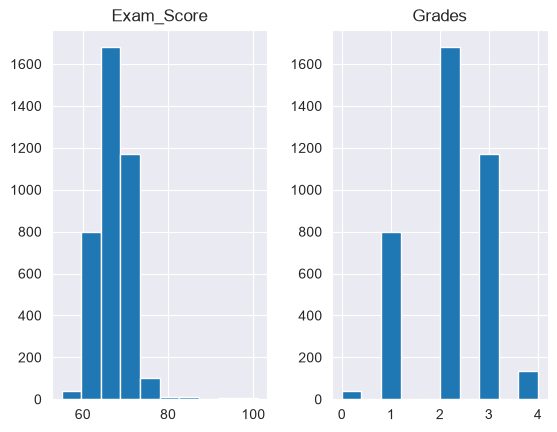

In [151]:
targets_train.hist()

## Baseline Models
This is the part where the three baseline models will be trained and tuned.
The baseline models include decision trees, naive bayes and linear regression.

### Decision Trees

In [152]:
# Train a decision tree with default hyperparameters
dt_default = DecisionTreeClassifier(random_state=21)
dt_default.fit(features_train, targets_train['Grades'])


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

The outputs from over results in what we call overfitting. Overfitting means the model has essentially memorized the training data instead of learning general patterns that hold up on new, unseen data. It's easy to spot when training data, and validation has a big gap, like the results we just got.

In [153]:
# Tune max_depth hyperparameter
# Starting with max_depth=5
dt_maxdepth_5 = DecisionTreeClassifier(max_depth=5, random_state=21)
dt_maxdepth_5.fit(features_train, targets_train['Grades'])


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

However, when we limit model to a max_depth, forces the tree to stop after N splits and make its prediction based on a broader, less specific group of training examples at that leaf.

In [154]:
# Trying with 3,5,7,10 and None for more depths/criterias
for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=21)
    dt.fit(features_train, targets_train['Grades'])
    print(f'max_depth={depth}') #f updates the string with the value of depth


max_depth=3
max_depth=5
max_depth=7
max_depth=10
max_depth=None


In [155]:
#A more cleaner way of presenting the results. 
#Intorducing max_depth=15 to see if it improves the model
results = []
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=21)
    dt.fit(features_train, targets_train['Grades'])
    train_acc = accuracy_score(targets_train['Grades'], dt.predict(features_train))
    val_acc = accuracy_score(targets_validation['Grades'], dt.predict(features_validation))
    results.append({'max_depth': depth, 'train_acc': train_acc, 'val_acc': val_acc})

pd.DataFrame(results)

,max_depth,train_acc,val_acc
0,3.0,0.630162,0.637147
1,5.0,0.696027,0.682602
2,7.0,0.771302,0.668495
3,10.0,0.897020,0.674765
4,15.0,0.996864,0.655956
5,NaN,1.000000,0.647335


In [156]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 10, 20], #2 is default by sklearn
}
#Total combinations: 6﷿﷿﷿﷿﷿﷿4﷿﷿﷿﷿﷿﷿3﷿﷿﷿﷿﷿﷿2= 144 different decision trees:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=21),
    param_grid,
    scoring='f1_weighted',     
    n_jobs=-1                  #forces to use all CPU cores, which speeds this up a lot (144 trees takes time)
)
grid_search.fit(features_train, targets_train['Grades'])

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)
dt_best = grid_search.best_estimator_


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

### Naive Bayes

In [98]:

# Create a default naive bayes classifier
default_nb = GaussianNB()
default_nb.fit(features_train, targets_train)




C:\Users\47480\Documents\Programmering 1\Eksamen\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](5,)","[ 40., 795.,1660.,1187., 144.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](5,)","[0.01,0.21,0.43,0.31,0.04]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](5,)","[0,1,2,3,4]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.009e-10
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](5, 19)","[[-0.23,-0.41, 0.9 ,..., 0.5 , 0.82, 0.6 ], [-0.09,-0.26, 0.93,..., 0.55, 0.59, 0.57], [-0.01,-0.04, 1.07,..., 0.7 , 0.51, 0.57], [ 0.06, 0.21, 1.19,..., 0.78, 0.43, 0.59], [ 0.16, 0.29, 1.35,..., 0.9 , 0.44, 0.51]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](5, 19)","[[0.01,0.01,0.44,...,0.45,0.74,0.24], [0.01,0.04,0.47,...,0.51,0.48,0.24], [0.02,0.06,0.47,...,0.61,0.46,0.25], [0.02,0.04,0.48,...,0.63,0.38,0.24], [0.02,0.05,0.42,...,0.67,0.39,0.25]]"


### Linear Classification

In [157]:
#Vi har et multiclass problem, bruker derfor SGDClassifier
sgd_default = SGDClassifier()
sgd_default.fit(features_train, targets_train['Grades'])

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

In [158]:
results = []
for loss in ["hinge", "log_loss", "perceptron"]:
    sgdc = SGDClassifier(loss=loss, random_state=21)
    sgdc.fit(features_train, targets_train['Grades'])
    train_acc = accuracy_score(targets_train['Grades'], sgdc.predict(features_train))
    val_acc = accuracy_score(targets_validation['Grades'], sgdc.predict(features_validation))
    results.append({'loss': loss, 'train_acc': train_acc, 'val_acc': val_acc})

pd.DataFrame(results)

,loss,train_acc,val_acc
0,hinge,0.814428,0.806426
1,log_loss,0.784370,0.774295
2,perceptron,0.758756,0.753918


Hinge gave the best results, moving on to tuning penalty while keeping loss="hinge"

In [160]:
results = []
for penalty in ["l1", "l2", "elasticnet"]:
    sgdc = SGDClassifier(loss="hinge",penalty=penalty,random_state=21)
    sgdc.fit(features_train, targets_train['Grades'])
    train_acc = accuracy_score(targets_train['Grades'], sgdc.predict(features_train))
    val_acc = accuracy_score(targets_validation['Grades'], sgdc.predict(features_validation))
    results.append({'penalty': penalty, 'train_acc': train_acc, 'val_acc': val_acc})

pd.DataFrame(results)

,penalty,train_acc,val_acc
0,l1,0.880554,0.869122
1,l2,0.814428,0.806426
2,elasticnet,0.730789,0.725705


l1 gave the best results, moving on to tuning alpha while keeping loss="hinge" and penalty="l1"

In [161]:
results = []
for alpha in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    sgdc = SGDClassifier(loss="hinge",penalty="l1", alpha=alpha,random_state=21)
    sgdc.fit(features_train, targets_train['Grades'])
    train_acc = accuracy_score(targets_train['Grades'], sgdc.predict(features_train))
    val_acc = accuracy_score(targets_validation['Grades'], sgdc.predict(features_validation))
    results.append({'alpha': alpha, 'train_acc': train_acc, 'val_acc': val_acc})

pd.DataFrame(results)

,alpha,train_acc,val_acc
0,0.100000,0.208573,0.208464
1,0.010000,0.612128,0.615204
2,0.001000,0.799007,0.799373
3,0.000100,0.880554,0.869122
4,0.000010,0.769733,0.771944
5,0.000001,0.730005,0.727273


Alpha=1e-4 gave the best result, so we'll make a tuned model with alpha=1e-4, loss="hinge" and penalty="l1"

In [162]:
# Tuning a SGDClassifier model, starting with loss
sgd_best = SGDClassifier(alpha=1e-4,penalty = "l1", random_state=21)
sgd_best.fit(features_train, targets_train['Grades'])

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",21
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

## Evaluation and Comparison
For this part the models will be compared and evaluated on different metrics.

We need to decide which metric fits our scenario.

In [166]:
# Tentative functions for tuning models.
# Used to evaluate hyperparameter tuning
def validation(model):
    train_predictions = model.predict(features_train)
    validation_predictions = model.predict(features_validation)
    print(f'Training Accuracy: {accuracy_score(targets_train["Grades"], train_predictions,):.2f} Validation: {accuracy_score(targets_validation["Grades"], validation_predictions):.2f}')
    print(f'Training Precision: {precision_score(targets_train["Grades"], train_predictions, average="weighted", zero_division=0):.2f} Validation: {precision_score(targets_validation["Grades"], validation_predictions, average="weighted", zero_division=0):.2f}')
    print(f'Training Recall: {recall_score(targets_train["Grades"], train_predictions, average="weighted", zero_division=0):.2f} Validation: {recall_score(targets_validation["Grades"], validation_predictions, average="weighted", zero_division=0):.2f}')
    print(f'Training F1: {f1_score(targets_train["Grades"], train_predictions, average="weighted", zero_division=0):.2f} Validation: {f1_score(targets_validation["Grades"], validation_predictions, average="weighted", zero_division=0):.2f}')

In [167]:
# Looking at how the tuned sgd model performs in training
validation(sgd_best)

Training Accuracy: 0.88 Validation: 0.87
Training Precision: 0.89 Validation: 0.84
Training Recall: 0.88 Validation: 0.87
Training F1: 0.86 Validation: 0.85


### Decision Trees

In [ ]:
# Perform validation
validation(dt_default)

validation(dt_maxdepth_5)

validation(dt)

validation(dt_best)

### Naive Bayes

In [ ]:
validation(default_nb)

## Confusion Matrices

In [180]:
# A function for plotting a confusion matrix for a model on test data.
def show_confusion(model, ax, title):
    predictions = model.predict(features_test)
    confusion = confusion_matrix(targets_test["Grades"], predictions)
    display = ConfusionMatrixDisplay(confusion)
    display.plot(ax=ax)
    ax.set_title(title)

Plotting confusion matrices side by side, comparing the default model with no tuning to the models with the best results. 

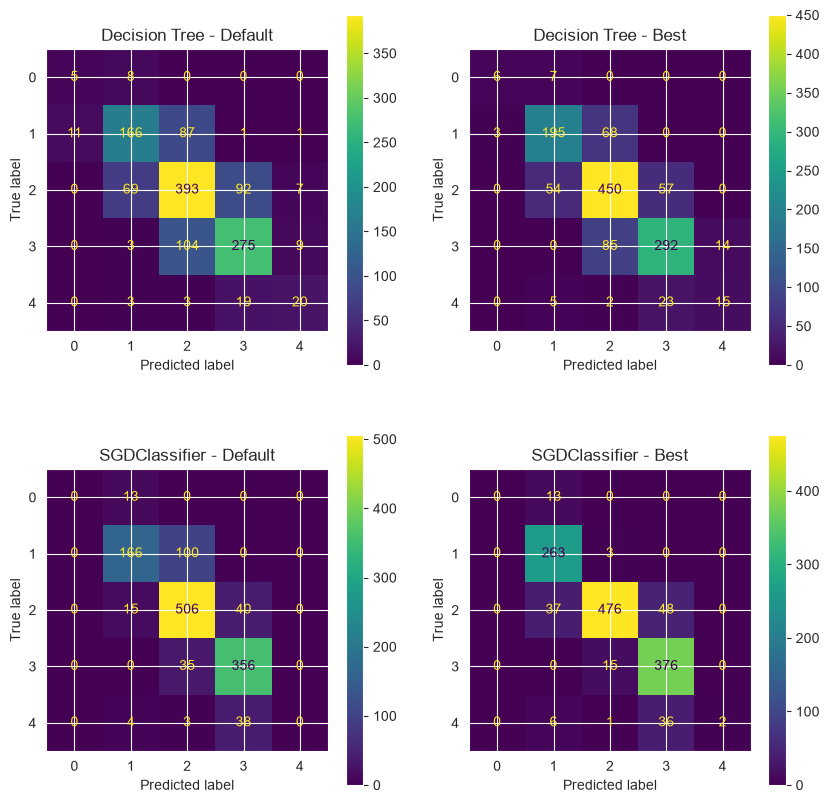

In [182]:
fig, axes = plt.subplots(2,2, figsize=(10,10)) 
show_confusion(dt_default, axes[0,0], "Decision Tree - Default")
show_confusion(dt_best, axes[0,1], "Decision Tree - Best")
show_confusion(sgd_default, axes[1,0], "SGDClassifier - Default")
show_confusion(sgd_best, axes[1,1],"SGDClassifier - Best")
#show_confusion(default_nb, axes[2,0], "Naive Bayes - Default")
#show_confusion(best_nb, axes[2,1], "Naive Bayes - Best"
plt.show()